In [ ]:
# Re-importing necessary library as the environment state has reset
import pandas as pd

# Load the newly uploaded dataset
file_path_new = '/content/final bhadla solar plant 6 months data.csv'

# Attempt to read the new dataset
data_new = pd.read_csv(file_path_new)

# Display the first few rows and dataset info to understand its structure
data_new.head(), data_new.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4416 entries, 0 to 4415
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       4416 non-null   int64  
 1   Month                      4416 non-null   int64  
 2   Day                        4416 non-null   int64  
 3   Hour                       4416 non-null   int64  
 4   Temperature                4416 non-null   float64
 5   Relative Humidity (2m)     4416 non-null   float64
 6   Surface Pressure(Kpa)      4416 non-null   float64
 7   Wind speed (10m)           4416 non-null   float64
 8   Wind direction (10m)       4416 non-null   float64
 9   Solar zenith angle(deg)    4416 non-null   float64
 10  Shortwave down Irradiance  4416 non-null   float64
 11  Corrected Precipitation    4416 non-null   float64
 12  Specific Humidity (2m)     4416 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 448.6 KB


(   Year  Month  Day  Hour  Temperature  Relative Humidity (2m)  \
 0  2022      3    1     0        16.90                   33.12   
 1  2022      3    1     1        16.23                   34.69   
 2  2022      3    1     2        15.51                   36.56   
 3  2022      3    1     3        14.96                   38.31   
 4  2022      3    1     4        14.51                   39.62   
 
    Surface Pressure(Kpa)  Wind speed (10m)  Wind direction (10m)  \
 0                  98.56              3.23                 78.01   
 1                  98.51              3.26                 88.90   
 2                  98.48              3.29                 99.15   
 3                  98.47              3.31                107.75   
 4                  98.50              3.34                113.74   
 
    Solar zenith angle(deg)  Shortwave down Irradiance  \
 0                   -999.0                        0.0   
 1                   -999.0                        0.0   
 2    

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
# Features and Target
X = data_new[
    [
        "Temperature",
        "Relative Humidity (2m)",
        "Surface Pressure(Kpa)",
        "Wind speed (10m)",
        "Wind direction (10m)",
        "Solar zenith angle(deg)",
        "Specific Humidity (2m)"
    ]
]
y = data_new["Shortwave down Irradiance"]

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
# SVR Model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)

In [ ]:
# Evaluate Models
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)

In [ ]:
print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}")
print(f"SVR - MSE: {svr_mse:.2f}, MAE: {svr_mae:.2f}")

Random Forest - MSE: 58268.53, MAE: 181.14
SVR - MSE: 119220.98, MAE: 256.97


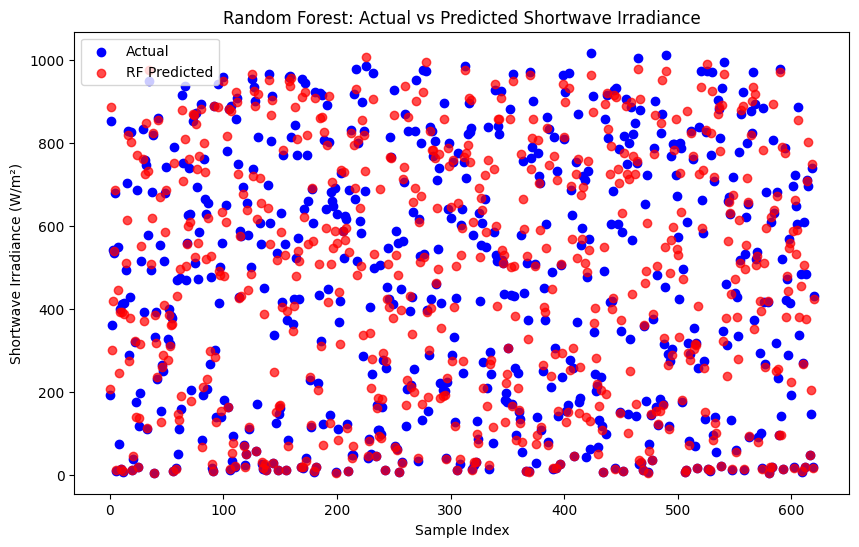

In [ ]:
# Plot Actual vs Predicted for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(rf_pred)), rf_pred, color='red', alpha=0.7, label='RF Predicted')
plt.title("Random Forest: Actual vs Predicted Shortwave Irradiance")
plt.xlabel("Sample Index")
plt.ylabel("Shortwave Irradiance (W/m²)")
plt.legend()
plt.show()

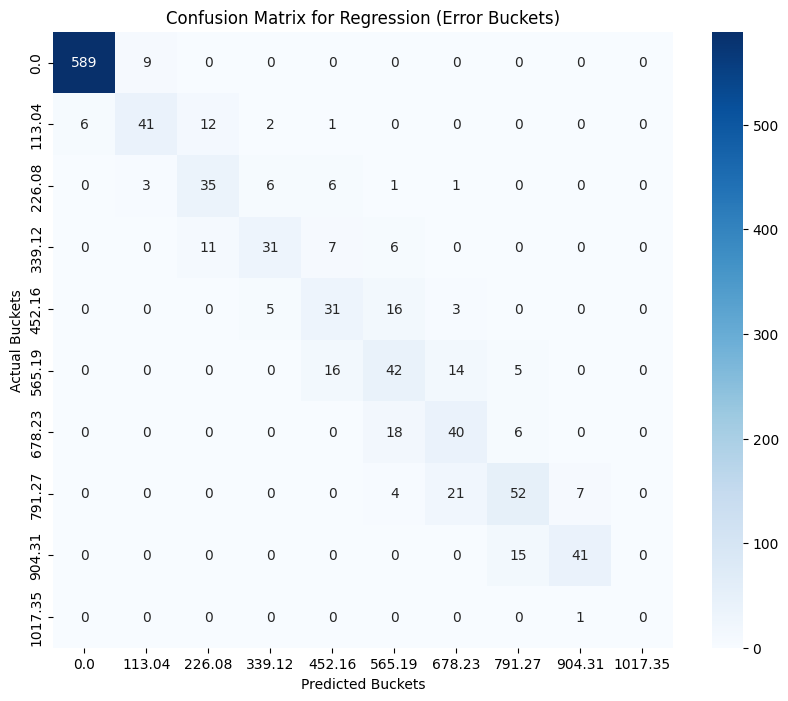

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define error buckets
bins = np.linspace(min(y_test), max(y_test), 10)  # 10 ranges
y_test_binned = np.digitize(y_test, bins)
rf_pred_binned = np.digitize(rf_pred, bins)

# Confusion Matrix
cm = confusion_matrix(y_test_binned, rf_pred_binned)

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bins.round(2), yticklabels=bins.round(2))
plt.xlabel("Predicted Buckets")
plt.ylabel("Actual Buckets")
plt.title("Confusion Matrix for Regression (Error Buckets)")
plt.show()


Mean Squared Error (MSE): 2871.187741589174
Mean Absolute Error (MAE): 30.43190837919897
R² Score: 0.9747545133551194


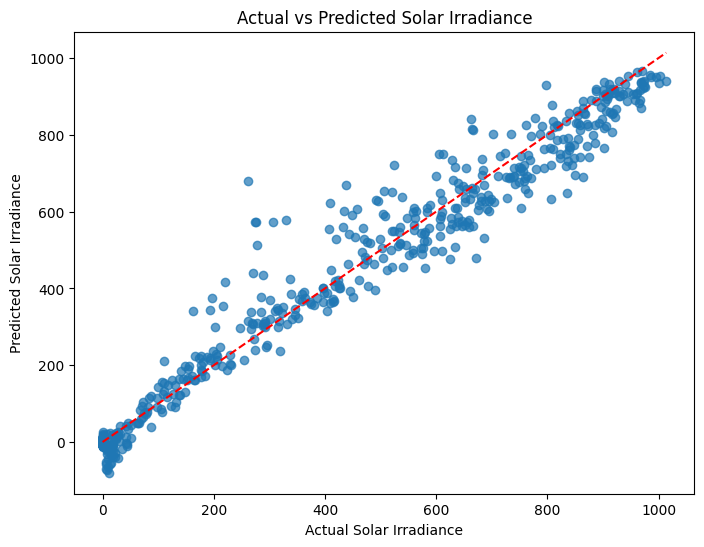

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Load the dataset
data = pd.read_csv('/content/final bhadla solar plant 6 months data.csv')

# Preprocess the data
# Assuming columns like 'temperature', 'pressure', 'humidity', etc., are present
# Features and Target
X = data_new[
    [
        "Temperature",
        "Relative Humidity (2m)",
        "Surface Pressure(Kpa)",
        "Wind speed (10m)",
        "Wind direction (10m)",
        "Solar zenith angle(deg)",
        "Specific Humidity (2m)"
    ]
]
y = data_new["Shortwave down Irradiance"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP Regressor
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Train the model
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

# Scatter plot of actual vs predicted values
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red')
plt.xlabel("Actual Solar Irradiance")
plt.ylabel("Predicted Solar Irradiance")
plt.title("Actual vs Predicted Solar Irradiance")
plt.show()


   Year  Month  Day  Hour  Temperature  Relative Humidity (2m)  \
0  2022      3    1     0        16.90                   33.12   
1  2022      3    1     1        16.23                   34.69   
2  2022      3    1     2        15.51                   36.56   
3  2022      3    1     3        14.96                   38.31   
4  2022      3    1     4        14.51                   39.62   

   Surface Pressure(Kpa)  Wind speed (10m)  Wind direction (10m)  \
0                  98.56              3.23                 78.01   
1                  98.51              3.26                 88.90   
2                  98.48              3.29                 99.15   
3                  98.47              3.31                107.75   
4                  98.50              3.34                113.74   

   Solar zenith angle(deg)  Shortwave down Irradiance  \
0                   -999.0                        0.0   
1                   -999.0                        0.0   
2                   -99

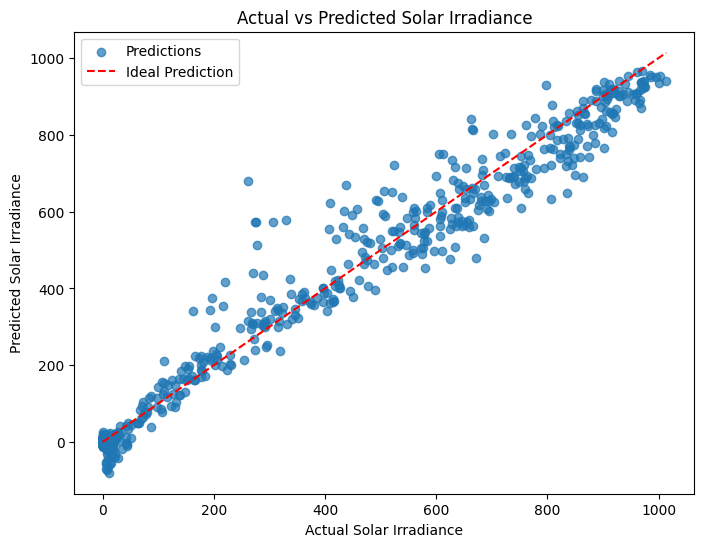

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('/content/final bhadla solar plant 6 months data.csv')

# Display the first few rows of the dataset to understand its structure
print(data.head())

# Assuming the dataset has these columns:
# 'temperature', 'pressure', 'humidity', 'wind_direction', 'wind_speed', 'sunrise', 'sunset', 'solar_irradiance'

# Features and target variable
X = data_new[
    [
        "Temperature",
        "Relative Humidity (2m)",
        "Surface Pressure(Kpa)",
        "Wind speed (10m)",
        "Wind direction (10m)",
        "Solar zenith angle(deg)",
        "Specific Humidity (2m)"
    ]
]
y = data_new["Shortwave down Irradiance"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Multi-Layer Perceptron Regressor
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Train the model
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

# Confusion Matrix (for regression, use binned values for classification-style visualization)
bins = np.linspace(min(y), max(y), 10)
y_test_binned = np.digitize(y_test, bins)
y_pred_binned = np.digitize(y_pred, bins)

confusion_matrix = pd.crosstab(y_test_binned, y_pred_binned, rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Matrix (Binned Values):")
print(confusion_matrix)

# Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', label="Ideal Prediction")
plt.xlabel("Actual Solar Irradiance")
plt.ylabel("Predicted Solar Irradiance")
plt.title("Actual vs Predicted Solar Irradiance")
plt.legend()
plt.show()
